In [3]:
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/parts_dataset.csv")

In [5]:
df.shape

(100, 6)

In [6]:
df.head()

,part_id,material,features,tolerance,batch_size,operations
0,P001,Aluminum,Chamfer,0.02mm,260,Facing;Drilling;Milling;Inspection
1,P002,Aluminum,Chamfer;Groove;Hole,0.1mm,442,Facing;Drilling;Milling;Inspection
2,P003,Aluminum,Slot,0.1mm,626,Facing;Drilling;Milling;Inspection
3,P004,Steel,Chamfer;Groove;Pocket,0.01mm,469,Facing;Center_Drilling;Drilling;Reaming;Inspec...
4,P005,Aluminum,Chamfer,0.05mm,358,Facing;Drilling;Milling;Inspection


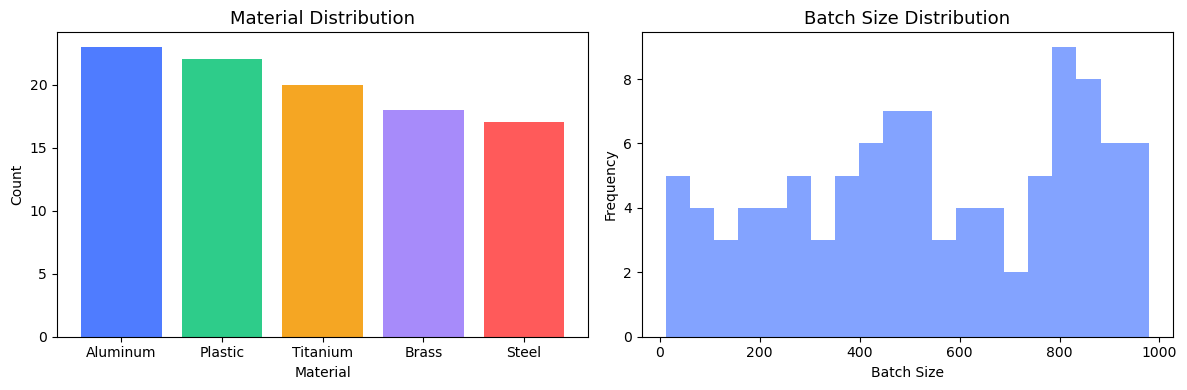

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: Material distribution
mat_counts = df["material"].value_counts()
axes[0].bar(mat_counts.index, mat_counts.values,
            color=["#4f7cff","#2ecc8a","#f5a623","#a78bfa","#ff5a5a"])
axes[0].set_title("Material Distribution", fontsize=13)
axes[0].set_xlabel("Material")
axes[0].set_ylabel("Count")

# Graph 2: Batch size distribution
axes[1].hist(df["batch_size"], bins=20, color="#4f7cff", alpha=0.7)
axes[1].set_title("Batch Size Distribution", fontsize=13)
axes[1].set_xlabel("Batch Size")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("../data/analysis_plots.png", dpi=150)
plt.show()

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import sys
sys.path.append('..')
from src.preprocessor import CAPPPreprocessor

In [9]:
prep = CAPPPreprocessor()
X, y, df2 = prep.preprocess("../data/parts_dataset.csv")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Data loaded: 100 rows, 6 columns
Material encoding:
  Aluminum = 0
  Brass = 1
  Plastic = 2
  Steel = 3
  Titanium = 4

Unique operation sequences: 8

Processed data saved: data/processed_dataset.csv
X shape: (100, 9)
y shape: (100,)
Feature columns: ['material_encoded', 'tolerance_score', 'batch_size', 'feat_Hole', 'feat_Slot', 'feat_Thread', 'feat_Pocket', 'feat_Groove', 'feat_Chamfer']


In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
acc = accuracy_score(y_test, rf.predict(X_test))

In [11]:
print(f"Model Accuracy: {acc*100:.1f}%")
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Model Accuracy: 75.0%
Train size: 80 | Test size: 20
